# SPY — Modeling and Analysis (Iteration 3)

Walk-forward config: **train=3d / test=1d / embargo=0d** (~2,500+ folds)

This notebook covers walk-forward model training and evaluation for **SPY** (S&P 500 ETF).
Features, targets, and models are identical to Iteration 2. Only the window configuration changes.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from xgboost import XGBRegressor

In [15]:
# ── Load data ─────────────────────────────────────────────────────────────
spy_raw  = pd.read_csv("data/SPY_features.csv",  parse_dates=["date"], index_col="date")
tsla_raw = pd.read_csv("data/TSLA_features.csv", parse_dates=["date"], index_col="date")

print(f"SPY:  {len(spy_raw):,} rows | {spy_raw.index[0].date()} \u2192 {spy_raw.index[-1].date()}")
print(f"TSLA: {len(tsla_raw):,} rows (loaded for correlation chart only)")

SPY:  2,515 rows | 2015-01-02 → 2024-12-30
TSLA: 2,515 rows (loaded for correlation chart only)


In [16]:
# ── Feature set ───────────────────────────────────────────────────────────
FEATURES = [
    # Price momentum
    "daily_return",    # today's % price change
    "weekly_return",   # 5-day % price change
    "lag_return_1",    # yesterday's return
    "lag_return_3",    # 3-day lagged return
    "lag_return_5",    # 5-day lagged return
    # Trend
    "dist_from_ma21",  # distance from 21-day moving average
    "ma_cross",        # 7-day MA > 21-day MA crossover signal
    # MACD
    "macd_hist",       # MACD histogram (crossover signal; macd/macd_signal removed — redundant)
    # Volatility
    "daily_range",     # intraday high-low spread / close
    "volatility_20",   # 20-day rolling std (volatility_7 removed — redundant with daily_range)
    "bb_position",     # Bollinger Band position
    # Volume
    "volume_change",   # day-over-day volume % change
    "volume_ratio",    # volume / 20-day average volume
    # Momentum oscillator
    "rsi_14",          # 14-day RSI
    # Event flags
    "is_major_event",  # VIX > 30
    "is_earnings_week",# earnings calendar flag
]

TRAIN_WINDOW = 3   # iter config
TEST_WINDOW  = 1    # iter config
EMBARGO      = 0 # trading days between train end and test start


def walk_forward_splits(df, train_window=TRAIN_WINDOW, test_window=TEST_WINDOW, embargo=EMBARGO):
    splits = []
    n = len(df)
    start = 0
    while start + train_window + embargo + test_window <= n:
        train_idx  = list(range(start, start + train_window))
        test_start = start + train_window + embargo
        test_idx   = list(range(test_start, test_start + test_window))
        splits.append((train_idx, test_idx))
        start += test_window
    return splits


def prepare_data(df, target_col, train_idx, test_idx):
    X = df[FEATURES].values
    y = df[target_col].values

    X_train, y_train = X[train_idx], y[train_idx]
    X_test,  y_test  = X[test_idx],  y[test_idx]

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, scaler


In [17]:
def run_linear_regression(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("LINEAR REGRESSION — 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, last_model = [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = LinearRegression()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        fold_metrics.append({"fold": fold, "mae": mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)), "r2": r2_score(y_test, preds)})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  ± {metrics_df[col].std():>9.6f}")
    print("\n  Feature coefficients (last fold):")
    coef_df = pd.DataFrame({"feature": FEATURES, "coefficient": last_model.coef_}).sort_values("coefficient", key=abs, ascending=False)
    print(coef_df.to_string(index=False))
    return last_model, metrics_df, preds_df


def run_logistic_regression(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("LOGISTIC REGRESSION — Predicting price direction")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, agg_cm, last_model = [], [], np.zeros((3, 3), dtype=int), None
    skipped = 0
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_direction", train_idx, test_idx)
        if len(np.unique(y_train)) < 2:
            skipped += 1
            continue
        model = LogisticRegression(max_iter=1000, C=0.1)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        report = classification_report(y_test, preds, output_dict=True, zero_division=0)
        fold_metrics.append({"fold": fold, "accuracy": accuracy_score(y_test, preds),
                              "precision": report["macro avg"]["precision"],
                              "recall": report["macro avg"]["recall"],
                              "f1": report["macro avg"]["f1-score"]})
        cm = confusion_matrix(y_test, preds, labels=[-1, 0, 1])
        agg_cm += cm
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    if skipped:
        print(f"  (skipped {skipped} single-class folds — expected with train={TRAIN_WINDOW}d window)")
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    print(f"\n  {'Metric':<12}  {'Mean':>8}  {'Std':>8}")
    print(f"  {'-'*32}")
    for col, label in [("f1", "F1"), ("precision", "Precision"), ("recall", "Recall"), ("accuracy", "Accuracy")]:
        print(f"  {label:<12}  {metrics_df[col].mean():>8.4f}  ± {metrics_df[col].std():>7.4f}")
    print("\n  Aggregate confusion matrix (all folds):")
    labels = ["Down", "Flat", "Up"]
    print(pd.DataFrame(agg_cm, index=[f"Actual {l}" for l in labels], columns=[f"Pred {l}" for l in labels]).to_string())
    print("\n  Feature log-odds (last fold):")
    coef_df = pd.DataFrame({"feature": FEATURES, "log_odds": last_model.coef_[0]}).sort_values("log_odds", key=abs, ascending=False)
    print(coef_df.to_string(index=False))
    return last_model, metrics_df, preds_df


def run_ridge_regression(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("RIDGE REGRESSION — 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, last_model = [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = Ridge(alpha=1.0)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        fold_metrics.append({"fold": fold, "mae": mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)), "r2": r2_score(y_test, preds)})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  ± {metrics_df[col].std():>9.6f}")
    print("\n  Feature coefficients (last fold):")
    coef_df = pd.DataFrame({"feature": FEATURES, "coefficient": last_model.coef_}).sort_values("coefficient", key=abs, ascending=False)
    print(coef_df.to_string(index=False))
    return last_model, metrics_df, preds_df


def run_xgboost(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("XGBOOST — 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, last_model = [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, verbosity=0)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        fold_metrics.append({"fold": fold, "mae": mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)), "r2": r2_score(y_test, preds)})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  ± {metrics_df[col].std():>9.6f}")
    print("\n  Feature importances (last fold):")
    imp_df = pd.DataFrame({"feature": FEATURES, "importance": last_model.feature_importances_}).sort_values("importance", ascending=False)
    print(imp_df.to_string(index=False))
    return last_model, metrics_df, preds_df


def run_random_forest(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("RANDOM FOREST — Predicting price direction")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, agg_cm, last_model = [], [], np.zeros((3, 3), dtype=int), None
    skipped = 0
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_direction", train_idx, test_idx)
        if len(np.unique(y_train)) < 2:
            skipped += 1
            continue
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        report = classification_report(y_test, preds, output_dict=True, zero_division=0)
        fold_metrics.append({"fold": fold, "accuracy": accuracy_score(y_test, preds),
                              "precision": report["macro avg"]["precision"],
                              "recall": report["macro avg"]["recall"],
                              "f1": report["macro avg"]["f1-score"]})
        cm = confusion_matrix(y_test, preds, labels=[-1, 0, 1])
        agg_cm += cm
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    if skipped:
        print(f"  (skipped {skipped} single-class folds — expected with train={TRAIN_WINDOW}d window)")
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    print(f"\n  {'Metric':<12}  {'Mean':>8}  {'Std':>8}")
    print(f"  {'-'*32}")
    for col, label in [("f1", "F1"), ("precision", "Precision"), ("recall", "Recall"), ("accuracy", "Accuracy")]:
        print(f"  {label:<12}  {metrics_df[col].mean():>8.4f}  ± {metrics_df[col].std():>7.4f}")
    print("\n  Aggregate confusion matrix (all folds):")
    labels = ["Down", "Flat", "Up"]
    print(pd.DataFrame(agg_cm, index=[f"Actual {l}" for l in labels], columns=[f"Pred {l}" for l in labels]).to_string())
    print("\n  Feature importances (last fold):")
    imp_df = pd.DataFrame({"feature": FEATURES, "importance": last_model.feature_importances_}).sort_values("importance", ascending=False)
    print(imp_df.to_string(index=False))
    return last_model, metrics_df, preds_df

In [18]:
SEASON_MAP = {
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall",  10: "Fall",  11: "Fall",
    12: "Winter", 1: "Winter", 2: "Winter"
}


def seasonal_summary(preds_df, task, label=""):
    df = preds_df.copy()
    df["season"] = pd.to_datetime(df["date"]).dt.month.map(SEASON_MAP)
    header = f"SEASONAL BREAKDOWN \u2014 {label}" if label else "SEASONAL BREAKDOWN"
    print("\n" + "="*55)
    print(header)
    print("="*55)
    season_order = ["Spring", "Summer", "Fall", "Winter"]
    rows = []
    if task == "regression":
        for season in season_order:
            s = df[df["season"] == season]
            if len(s) < 2: continue
            rows.append({"season": season, "n": len(s),
                         "rmse": round(np.sqrt(mean_squared_error(s["actual"], s["predicted"])), 6),
                         "mae":  round(mean_absolute_error(s["actual"], s["predicted"]), 6),
                         "r2":   round(r2_score(s["actual"], s["predicted"]), 4)})
    elif task == "classification":
        for season in season_order:
            s = df[df["season"] == season]
            if len(s) < 2: continue
            report = classification_report(s["actual"], s["predicted"], output_dict=True, zero_division=0)
            rows.append({"season": season, "n": len(s),
                         "f1":        round(report["macro avg"]["f1-score"], 4),
                         "precision": round(report["macro avg"]["precision"], 4),
                         "recall":    round(report["macro avg"]["recall"], 4),
                         "accuracy":  round(accuracy_score(s["actual"], s["predicted"]), 4)})
    print(pd.DataFrame(rows).to_string(index=False))
    return pd.DataFrame(rows)

## Exploratory Data Analysis — SPY (2015–2025)

VIX coverage: 2015-01-02 → 2024-12-30
Days VIX > 30: 144 (5.7%)
Max VIX: 82.69 on 2020-03-16


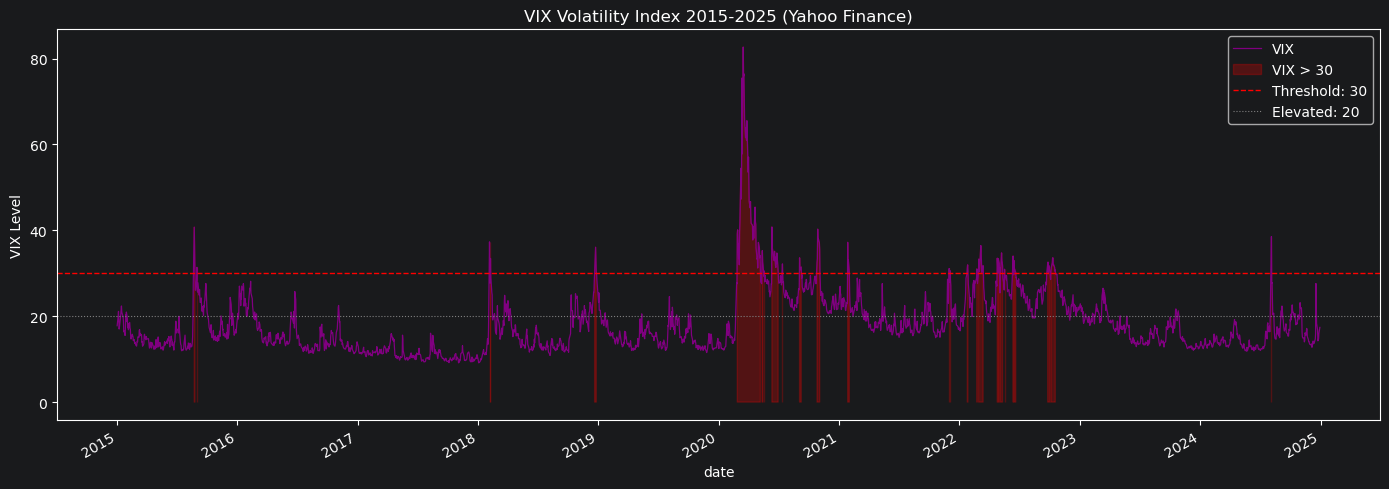

count    2515.00
mean       18.27
std         7.28
min         9.14
25%        13.35
50%        16.33
75%        21.32
max        82.69
Name: vix, dtype: float64


In [19]:
# VIX TIME SERIES
vix_series = spy_raw["vix"].dropna()
print(f"VIX coverage: {vix_series.index[0].date()} \u2192 {vix_series.index[-1].date()}")
print(f"Days VIX > 30: {(vix_series > 30).sum()} ({(vix_series > 30).mean()*100:.1f}%)")
print(f"Max VIX: {vix_series.max():.2f} on {vix_series.idxmax().date()}")

fig, ax = plt.subplots(figsize=(14, 5))
vix_series.plot(ax=ax, color="purple", linewidth=0.9, label="VIX")
ax.fill_between(vix_series.index, vix_series, where=vix_series > 30,
                color="red", alpha=0.25, label="VIX > 30")
ax.axhline(y=30, color="red",  linestyle="--", linewidth=1,   label="Threshold: 30")
ax.axhline(y=20, color="gray", linestyle=":",  linewidth=0.8, label="Elevated: 20")
ax.set_title("VIX Volatility Index 2015-2025 (Yahoo Finance)")
ax.set_ylabel("VIX Level")
ax.legend()
plt.tight_layout()
plt.savefig("img/vix_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print(vix_series.describe().round(2))

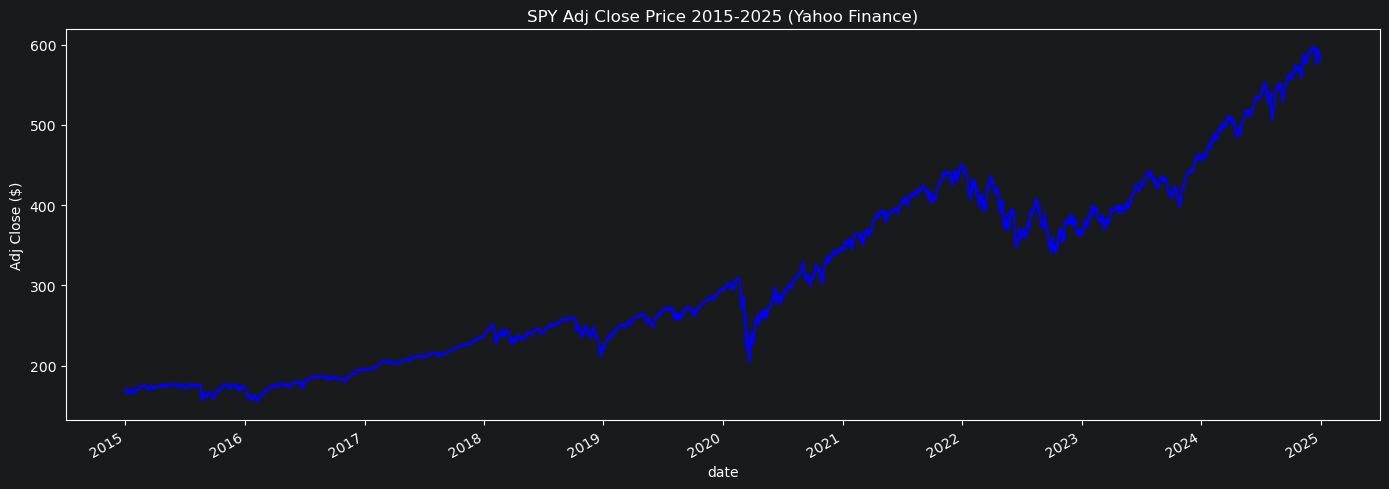

          open     high      low  adj_close        volume
count  2515.00  2515.00  2515.00    2515.00  2.515000e+03
mean    334.89   336.70   332.92     309.36  8.744808e+07
std     107.83   108.35   107.24     114.07  4.491431e+07
min     182.34   184.10   181.02     154.56  2.027000e+07
25%     242.90   244.04   241.79     211.59  5.898355e+07
50%     300.04   301.13   298.52     272.40  7.661080e+07
75%     420.25   422.80   417.61     398.14  1.022614e+08
max     607.69   609.07   607.02     597.11  5.072443e+08


In [20]:
# SPY CLOSE PRICE (adj_close — dividend adjusted)
fig, ax = plt.subplots(figsize=(14, 5))
spy_raw["adj_close"].plot(ax=ax, color="blue", title="SPY Adj Close Price 2015-2025 (Yahoo Finance)")
ax.set_ylabel("Adj Close ($)")
plt.tight_layout()
plt.savefig("img/spy_close_price.png", dpi=150, bbox_inches="tight")
plt.show()
print(spy_raw[["open","high","low","adj_close","volume"]].describe().round(2))

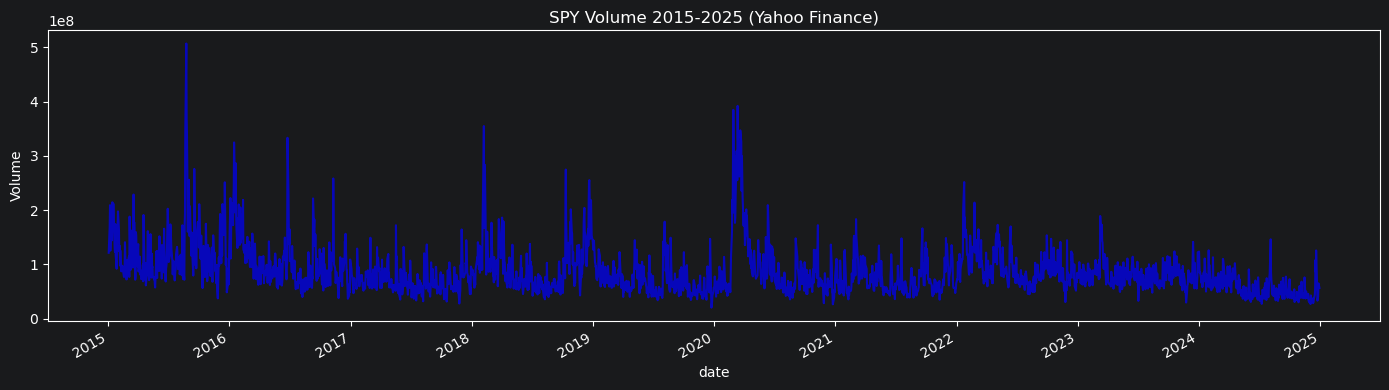

In [21]:
# SPY VOLUME
fig, ax = plt.subplots(figsize=(14, 4))
spy_raw["volume"].plot(ax=ax, color="blue", alpha=0.7, title="SPY Volume 2015-2025 (Yahoo Finance)")
ax.set_ylabel("Volume")
plt.tight_layout()
plt.savefig("img/spy_volume.png", dpi=150, bbox_inches="tight")
plt.show()

SPY vs TSLA correlation (Yahoo Finance):
         SPY    TSLA
SPY   1.0000  0.8718
TSLA  0.8718  1.0000


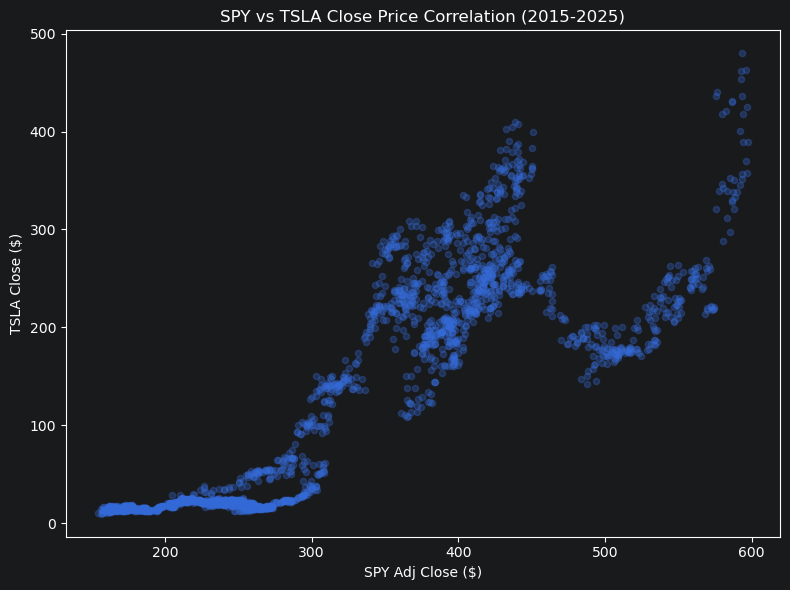

In [22]:
# SPY vs TSLA CLOSE PRICE CORRELATION
combined = pd.DataFrame({"SPY": spy_raw["adj_close"], "TSLA": tsla_raw["close"]})
print("SPY vs TSLA correlation (Yahoo Finance):")
print(combined.corr().round(4))
combined.plot.scatter(x="SPY", y="TSLA", alpha=0.3, figsize=(8, 6),
                      title="SPY vs TSLA Close Price Correlation (2015-2025)")
plt.xlabel("SPY Adj Close ($)")
plt.ylabel("TSLA Close ($)")
plt.tight_layout()
plt.savefig("img/spy_tsla_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

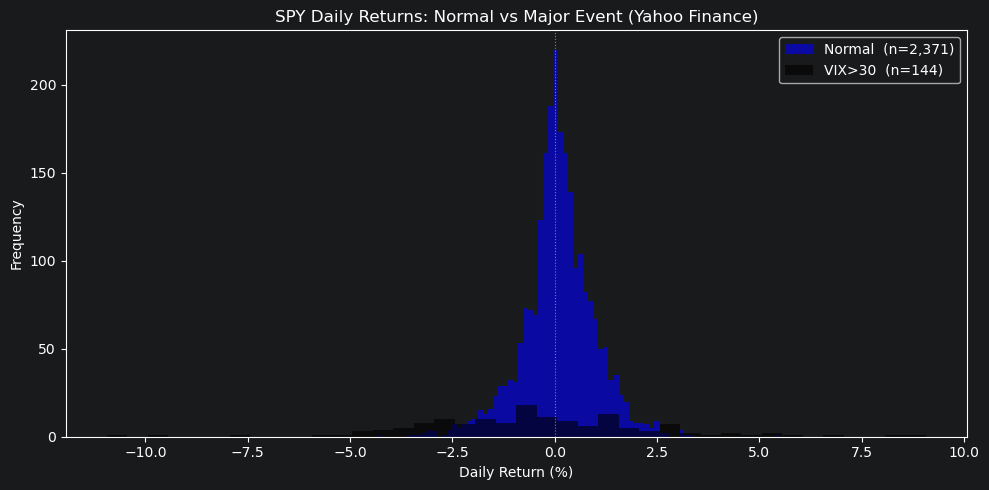

Normal days:  mean=0.0882%  std=0.8766%
Event days:   mean=-0.4934%  std=2.9323%


In [23]:
# VIX vs DAILY RETURNS — normal vs stress periods (SPY)
normal = spy_raw[spy_raw["is_major_event"] == 0]["daily_return"].dropna() * 100
event  = spy_raw[spy_raw["is_major_event"] == 1]["daily_return"].dropna() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(normal, bins=80, alpha=0.6, color="blue",  label=f"Normal  (n={len(normal):,})")
ax.hist(event,  bins=40, alpha=0.6, color="black", label=f"VIX>30  (n={len(event):,})")
ax.axvline(x=0, color="gray", linewidth=0.8, linestyle=":")
ax.set_title("SPY Daily Returns: Normal vs Major Event (Yahoo Finance)")
ax.set_xlabel("Daily Return (%)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig("img/spy_vix_vs_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Normal days:  mean={normal.mean():.4f}%  std={normal.std():.4f}%")
print(f"Event days:   mean={event.mean():.4f}%  std={event.std():.4f}%")

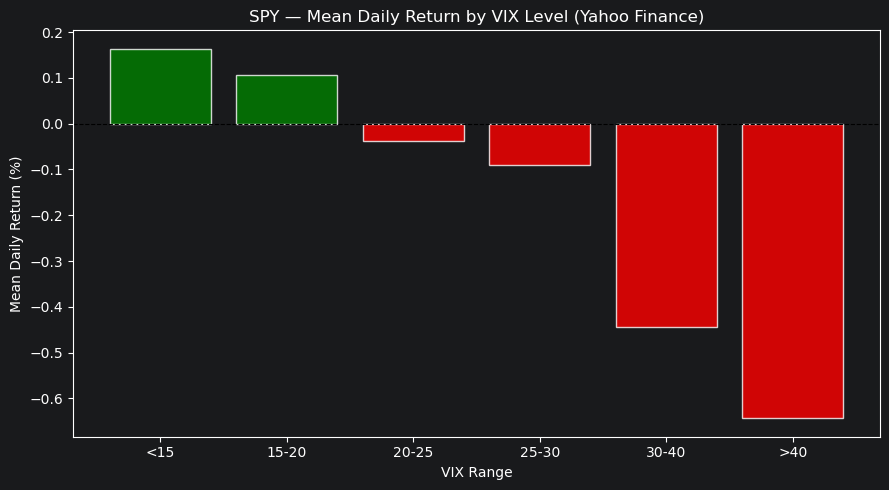

In [24]:
# VIX LEVEL vs MEAN DAILY RETURN (binned) — SPY
spy_eda = spy_raw.copy()
spy_eda["vix_bin"] = pd.cut(spy_eda["vix"], bins=[0, 15, 20, 25, 30, 40, 100],
                             labels=["<15","15-20","20-25","25-30","30-40",">40"])
binned = spy_eda.groupby("vix_bin", observed=True)["daily_return"].mean() * 100
bar_colors = ["green" if v >= 0 else "red" for v in binned.values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(binned.index, binned.values, color=bar_colors, alpha=0.8, edgecolor="white")
ax.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("SPY \u2014 Mean Daily Return by VIX Level (Yahoo Finance)")
ax.set_xlabel("VIX Range")
ax.set_ylabel("Mean Daily Return (%)")
plt.tight_layout()
plt.savefig("img/spy_vix_binned_returns.png", dpi=150, bbox_inches="tight")
plt.show()

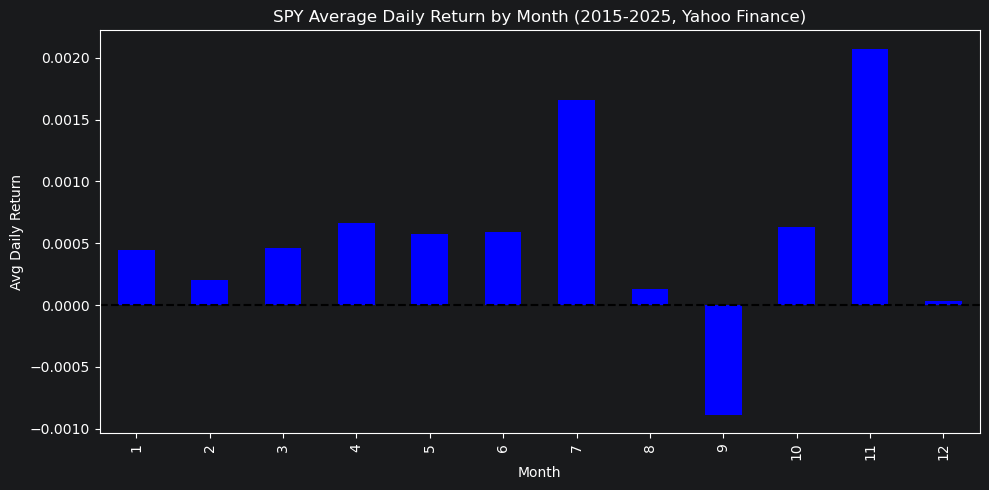

In [25]:
# AVERAGE DAILY RETURN BY MONTH — SPY
spy_eda["month"] = spy_eda.index.month

fig, ax = plt.subplots(figsize=(10, 5))
spy_eda.groupby("month")["daily_return"].mean().plot(
    kind="bar", ax=ax, color="blue",
    title="SPY Average Daily Return by Month (2015-2025, Yahoo Finance)")
ax.axhline(y=0, color="black", linestyle="--")
ax.set_xlabel("Month")
ax.set_ylabel("Avg Daily Return")
plt.tight_layout()
plt.savefig("img/spy_monthly_returns.png", dpi=150, bbox_inches="tight")
plt.show()

## SPY — Model Training and Evaluation

In [26]:
# ── Softened direction target (5b) ───────────────────────────────────────
# SPY threshold: 0.5% — smaller moves are classified as FLAT (0)
def soften_direction(pct_change, threshold):
    if pct_change > threshold:
        return 1    # UP
    elif pct_change < -threshold:
        return -1   # DOWN
    else:
        return 0    # FLAT

spy_raw["target_direction"] = (
    spy_raw["close"].pct_change(1).shift(-1)
    .apply(lambda x: soften_direction(x, threshold=0.005))
)

# ── Forward realized volatility target (5c) ───────────────────────────────
# std of the next 5 daily returns — features are better aligned to volatility than to return direction
spy_raw["target_volatility"] = (
    spy_raw["close"].pct_change()
    .shift(-1)
    .rolling(5)
    .std()
    .shift(-4)
)

# ── Prepare SPY modeling data ─────────────────────────────────────────────
required_cols = FEATURES + ["target_direction", "target_volatility"]
spy_df = spy_raw.dropna(subset=required_cols).copy()

print(f"Rows after dropping NaN: {len(spy_df):,}")
print(f"Date range: {spy_df.index.min().date()} \u2192 {spy_df.index.max().date()}")
print(f"Major event days (VIX > 30): {spy_df['is_major_event'].sum()}")
print(f"Earnings weeks:              {spy_df['is_earnings_week'].sum()}")
print(f"Walk-forward folds:          {len(walk_forward_splits(spy_df))}")
print(f"\ntarget_direction distribution:")
print(spy_df["target_direction"].value_counts().sort_index().rename({-1: "Down (-1)", 0: "Flat (0)", 1: "Up (1)"}))

# ── Regression models ─────────────────────────────────────────────────────
lin_model,   lin_metrics,   lin_preds   = run_linear_regression(spy_df)
seasonal_summary(lin_preds, "regression", "Linear Regression \u2014 SPY")

ridge_model, ridge_metrics, ridge_preds = run_ridge_regression(spy_df)
seasonal_summary(ridge_preds, "regression", "Ridge Regression \u2014 SPY")

xgb_model,   xgb_metrics,   xgb_preds   = run_xgboost(spy_df)
seasonal_summary(xgb_preds, "regression", "XGBoost \u2014 SPY")

# ── Classification models ─────────────────────────────────────────────────
log_model, log_metrics, log_preds = run_logistic_regression(spy_df)
seasonal_summary(log_preds, "classification", "Logistic Regression \u2014 SPY")

rf_model,  rf_metrics,  rf_preds  = run_random_forest(spy_df)
seasonal_summary(rf_preds, "classification", "Random Forest \u2014 SPY")

Rows after dropping NaN: 2,510
Date range: 2015-01-02 → 2024-12-20
Major event days (VIX > 30): 144
Earnings weeks:              420
Walk-forward folds:          2507

target_direction distribution:
target_direction
Down (-1)     549
Flat (0)     1261
Up (1)        700
Name: count, dtype: int64

LINEAR REGRESSION — 5-day forward volatility
Walk-forward: 2507 folds  (train=3d, test=1d)


/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning


  Metric          Mean         Std
  --------------------------------
  RMSE        0.002496  ±  0.004214
  MAE         0.002496  ±  0.004214
  R²               nan  ±       nan

  Feature coefficients (last fold):
         feature  coefficient
    volume_ratio    -0.000565
     daily_range    -0.000548
   weekly_return     0.000517
     bb_position     0.000503
  dist_from_ma21     0.000487
   volatility_20    -0.000487
          rsi_14     0.000485
    daily_return     0.000456
    lag_return_5    -0.000446
       macd_hist     0.000347
   volume_change    -0.000331
        ma_cross     0.000299
    lag_return_3    -0.000292
    lag_return_1     0.000128
  is_major_event     0.000000
is_earnings_week     0.000000

SEASONAL BREAKDOWN — Linear Regression — SPY
season   n     rmse      mae      r2
Spring 638 0.004699 0.002462  0.8036
Summer 645 0.004527 0.002399  0.3016
  Fall 630 0.005857 0.002684 -0.2206
Winter 594 0.004345 0.002439  0.3954

RIDGE REGRESSION — 5-day forward volatilit

/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning


  Metric          Mean         Std
  --------------------------------
  RMSE        0.002433  ±  0.004024
  MAE         0.002433  ±  0.004024
  R²               nan  ±       nan

  Feature coefficients (last fold):
         feature  coefficient
    volume_ratio    -0.000541
     daily_range    -0.000523
   weekly_return     0.000499
     bb_position     0.000485
  dist_from_ma21     0.000471
   volatility_20    -0.000471
          rsi_14     0.000469
    daily_return     0.000432
    lag_return_5    -0.000423
       macd_hist     0.000339
   volume_change    -0.000311
        ma_cross     0.000293
    lag_return_3    -0.000287
    lag_return_1     0.000131
  is_major_event     0.000000
is_earnings_week     0.000000

SEASONAL BREAKDOWN — Ridge Regression — SPY
season   n     rmse      mae      r2
Spring 638 0.004539 0.002407  0.8167
Summer 645 0.004383 0.002344  0.3453
  Fall 630 0.005569 0.002607 -0.1037
Winter 594 0.004173 0.002373  0.4424

XGBOOST — 5-day forward volatility
Walk-for

/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/donnguyen/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning


  Metric          Mean         Std
  --------------------------------
  RMSE        0.002181  ±  0.002797
  MAE         0.002181  ±  0.002797
  R²               nan  ±       nan

  Feature importances (last fold):
         feature  importance
   weekly_return     0.85989
    daily_return     0.14011
    lag_return_1     0.00000
    lag_return_3     0.00000
    lag_return_5     0.00000
  dist_from_ma21     0.00000
        ma_cross     0.00000
       macd_hist     0.00000
     daily_range     0.00000
   volatility_20     0.00000
     bb_position     0.00000
   volume_change     0.00000
    volume_ratio     0.00000
          rsi_14     0.00000
  is_major_event     0.00000
is_earnings_week     0.00000

SEASONAL BREAKDOWN — XGBoost — SPY
season   n     rmse      mae     r2
Spring 638 0.003912 0.002332 0.8639
Summer 645 0.003269 0.002025 0.6357
  Fall 630 0.003334 0.002166 0.6045
Winter 594 0.003638 0.002202 0.5762

LOGISTIC REGRESSION — Predicting price direction
Walk-forward: 2507 folds  

,season,n,f1,precision,recall,accuracy
0,Spring,529,0.3540,0.3538,0.3579,0.3951
1,Summer,488,0.3286,0.3288,0.3329,0.3934
2,Fall,464,0.3766,0.3795,0.3771,0.4246
3,Winter,489,0.3731,0.3720,0.3772,0.4110
